In [1]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
run_name = "ch12"

data_dir = Path("data") / "ch12"
tsv = data_dir / "training.tsv"

In [3]:
df = pd.read_csv(tsv, sep='\t')
df = df.sort_values(by='step', ascending=True)
df = df.drop_duplicates(subset=['step', 'split'], keep='last')

train_df = df.loc[df['split'] == 'train', :]
eval_df = df.loc[df['split'] == 'eval', :]

df.nsmallest(10, 'loss')

,step,epoch,split,loss,learning_rate,created_at
133,5800,188,train,0.004,0.000250,2025-11-10T13:14:24+08:00
134,5850,189,train,0.004,0.000249,2025-11-10T13:16:16+08:00
130,5650,183,train,0.005,0.000253,2025-11-10T13:08:56+08:00
131,5700,184,train,0.005,0.000252,2025-11-10T13:10:45+08:00
132,5750,186,train,0.006,0.000251,2025-11-10T13:12:35+08:00
99,4300,139,train,0.007,0.000274,2025-09-30T13:56:38%:z
128,5550,180,train,0.008,0.000254,2025-11-10T13:05:24+08:00
129,5600,181,train,0.008,0.000253,2025-11-10T13:07:10+08:00
98,4250,138,train,0.009,0.000275,2025-09-30T13:53:47%:z
100,4350,141,train,0.009,0.000273,2025-09-30T13:59:26%:z


In [4]:
train_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
128,5550,180,train,0.008,0.000254,2025-11-10T13:05:24+08:00
129,5600,181,train,0.008,0.000253,2025-11-10T13:07:10+08:00
130,5650,183,train,0.005,0.000253,2025-11-10T13:08:56+08:00
131,5700,184,train,0.005,0.000252,2025-11-10T13:10:45+08:00
132,5750,186,train,0.006,0.000251,2025-11-10T13:12:35+08:00
133,5800,188,train,0.004,0.000250,2025-11-10T13:14:24+08:00
134,5850,189,train,0.004,0.000249,2025-11-10T13:16:16+08:00
135,5900,191,train,0.010,0.000248,2025-11-10T13:18:06+08:00
136,5950,192,train,0.012,0.000247,2025-11-10T13:19:59+08:00
137,6000,194,train,0.022,0.000246,2025-11-10T13:21:50+08:00


In [5]:
eval_df.tail(10)

,step,epoch,split,loss,learning_rate,created_at
32,1500,49,eval,10.494,NaN,2025-09-30T10:00:14%:z
43,2000,65,eval,11.816,NaN,2025-09-30T10:28:34%:z
60,2500,81,eval,12.692,NaN,2025-09-30T12:14:59%:z
71,3000,97,eval,13.342,NaN,2025-09-30T12:43:12%:z
82,3500,113,eval,13.377,NaN,2025-09-30T13:11:29%:z
93,4000,130,eval,14.067,NaN,2025-09-30T13:39:42%:z
104,4500,146,eval,14.106,NaN,2025-09-30T14:07:54%:z
115,5000,162,eval,14.233,NaN,2025-09-30T14:36:05%:z
127,5500,178,eval,7.150,NaN,2025-09-30T15:04:21%:z
138,6000,194,eval,14.820,NaN,2025-11-10T13:21:51+08:00


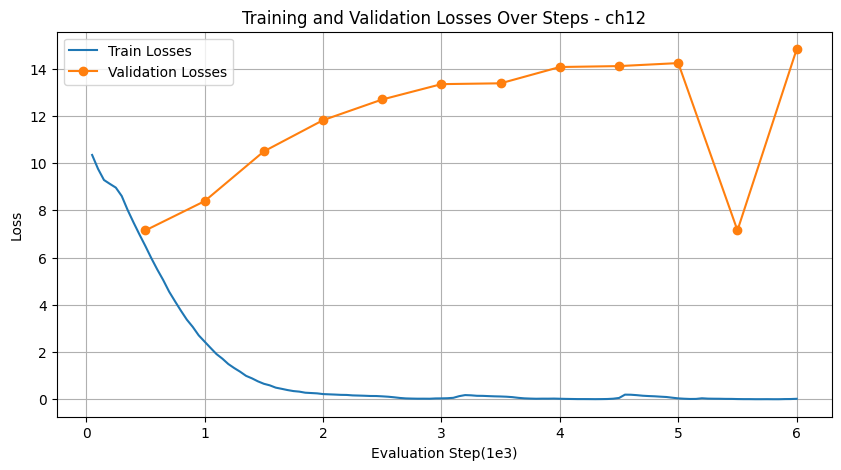

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['loss'], label="Train Losses")
plt.plot(eval_df['step']/1e3, eval_df['loss'], label="Validation Losses", marker='o')
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Loss")
#plt.xlim(0, max(1e6, df["step"].max()))

plt.title(f"Training and Validation Losses Over Steps - {run_name}")
plt.legend()
plt.grid()

#plt.show()
plt.savefig(data_dir / "training.pdf")

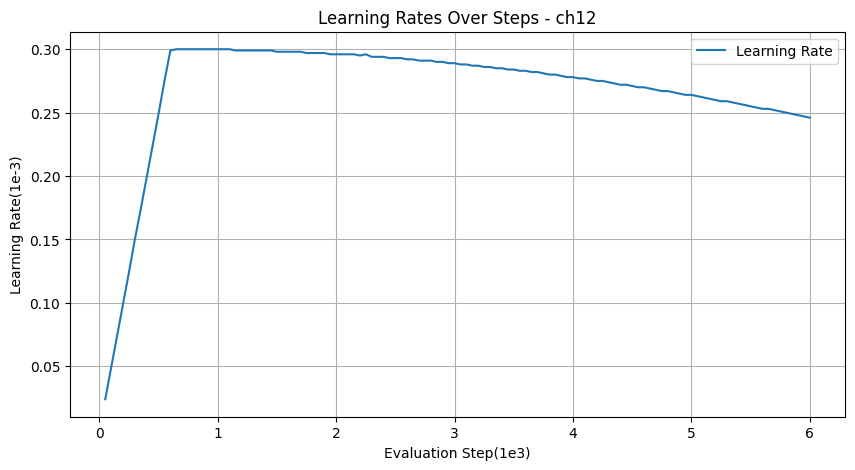

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_df['step']/1e3, train_df['learning_rate']*1e3, label="Learning Rate")
plt.xlabel("Evaluation Step(1e3)")
plt.ylabel("Learning Rate(1e-3)")
plt.title(f"Learning Rates Over Steps - {run_name}")
plt.legend()
plt.grid()
#plt.xlim(0, max(1e6, df["step"].max()))
#plt.show()
plt.savefig(data_dir / "learning_rate.pdf")